# 匹配与加权教程

### 用 LaLonde 的数据评估就业培训项目

没有随机实验，也没有工具变量和断点，只有一批参加了项目的人和一批没参加的人，以及他们的若干背景特征。能不能通过「控制可观测变量」估计出项目的因果效应？

这是观察性研究里最常见的处境。LaLonde (1986) 用一个巧妙的设计检验了这类方法。美国的 NSW 就业培训项目本身是随机实验，有一个可靠的实验估计。他把实验的对照组换成从普通住户调查里抽取的人，看非实验方法能不能找回实验的答案。Dehejia and Wahba (1999) 后来用倾向得分方法重新分析了这份数据。

本教程用随包自带的数据，把回归调整、倾向得分匹配、逆概率加权、熵平衡和双重稳健估计放在一起走一遍。重点不是哪个方法给出「正确」的数字，而是每一步该检查什么。全程离线。

| 节 | 内容 | 你会学到 |
| --- | --- | --- |
| 1 | 识别假设 | 条件独立与重叠，ATT 与 ATE |
| 2 | 数据 | 处理组、对照组、实验基准 |
| 3 | 两组差在哪里 | 平衡表与标准化均值差 |
| 4 | 回归调整 | 最简单的基准 |
| 5 | 倾向得分与重叠 | 两组的可比区域有多大 |
| 6 | 匹配 | 最近邻匹配，匹配之后必须重新检查平衡 |
| 7 | 逆概率加权 | 权重、有效样本量 |
| 8 | 熵平衡 | 直接把平衡当作约束 |
| 9 | 双重稳健 | 结果模型和倾向得分模型只要对一个 |
| 10 | 把所有估计放在一起 | 方法之间差多少 |
| 11 | 敏感性分析 | 未观测混淆要多强才能推翻结论 |
| 12 | 小结 | 一份清单 |

## 1. 识别假设

记 $D$ 为是否参加项目，$Y(1)$ 和 $Y(0)$ 为参加和不参加时的潜在收入，$X$ 为处理前的特征。本教程的所有方法都依赖同样的两个假设。

**条件独立**（也叫无混淆、可忽略性、selection on observables）。

$$
\big(Y(0),\, Y(1)\big) \;\perp\; D \mid X .
$$

给定 $X$ 之后，谁参加项目与潜在收入无关。换句话说，所有同时影响参加决定和收入的因素都已经包含在 $X$ 里了。这个假设**无法用数据检验**。它是否可信，取决于你对参加决定是怎么做出的有多少了解，以及 $X$ 有多丰富。

**重叠**（也叫共同支撑）。

$$
0 < P(D = 1 \mid X) < 1 .
$$

每一种特征组合下，都既有参加的人也有没参加的人。这个假设可以用数据检查。

两个假设都成立时，回归、匹配、加权是**同一个识别策略的不同估计方法**。它们的区别在于怎样使用 $X$，而不在于假设的强弱。如果条件独立不成立，换哪种方法都救不回来。

**估计目标**也要事先想清楚。

- ATE 是总体的平均效应，$E[Y(1) - Y(0)]$。
- ATT 是参加者的平均效应，$E[Y(1) - Y(0) \mid D = 1]$。

评估一个自愿参加的培训项目，关心的通常是 ATT，也就是项目对实际参加的人有没有用。本教程估计的都是 ATT。它只要求条件独立对 $Y(0)$ 成立，重叠也只要求 $P(D = 1 \mid X) < 1$，比 ATE 的要求弱。

In [1]:
import warnings

warnings.filterwarnings("ignore")  # 教程里隐藏无关提示，正式分析时建议保留

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statspai as sp

plt.rcParams["figure.dpi"] = 80
pd.set_option("display.width", 140)
print("StatsPAI 版本:", sp.__version__)

StatsPAI 版本: 1.39.2


## 2. 数据

`sp.datasets.nsw_lalonde()` 是 R `MatchIt` 包附带的那份 LaLonde 数据，共 614 人。

- **处理组** 185 人，是 NSW 实验中被随机分到培训的男性（Dehejia-Wahba 子样本）。
- **对照组** 429 人，来自 PSID 住户调查，不是实验的对照组。

| 变量 | 含义 |
| --- | --- |
| `treat` | 是否参加 NSW 培训 |
| `re78` | 1978 年实际收入（美元），**结果变量** |
| `re74`, `re75` | 1974、1975 年收入，培训之前 |
| `age`, `educ` | 年龄，受教育年限 |
| `black`, `hispanic` | 种族 |
| `married`, `nodegree` | 已婚，没有高中文凭 |

**实验基准**。用实验自己的对照组，Dehejia and Wahba (1999) 得到的效应是 1,794 美元。处理组是同一批人，所以这个数字就是我们想找回的 ATT。真实研究里没有这样的基准，这正是这份数据的教学价值。

In [2]:
df = sp.datasets.nsw_lalonde()
covs = ["age", "educ", "black", "hispanic", "married", "nodegree", "re74", "re75"]
BENCHMARK = 1794  # 实验估计，Dehejia and Wahba (1999)

print(df.shape, "| 处理组", int(df["treat"].sum()), "人，对照组", int((1 - df["treat"]).sum()), "人")
df[["treat", "re78"] + covs].head()

(614, 11) | 处理组 185 人，对照组 429 人


,treat,re78,age,educ,black,hispanic,married,nodegree,re74,re75
0,1,9930.0460,37,11,1,0,1,1,0.0,0.0
1,1,3595.8940,22,9,0,1,0,1,0.0,0.0
2,1,24909.4500,30,12,1,0,0,0,0.0,0.0
3,1,7506.1460,27,11,1,0,0,1,0.0,0.0
4,1,289.7899,33,8,1,0,0,1,0.0,0.0


## 3. 两组差在哪里

先看不做任何调整的比较。

In [3]:
naive = df.loc[df["treat"] == 1, "re78"].mean() - df.loc[df["treat"] == 0, "re78"].mean()
print(f"处理组平均收入 : {df.loc[df['treat'] == 1, 're78'].mean():8.0f}")
print(f"对照组平均收入 : {df.loc[df['treat'] == 0, 're78'].mean():8.0f}")
print(f"原始均值差     : {naive:8.0f}    (实验基准 {BENCHMARK})")

处理组平均收入 :     6349
对照组平均收入 :     6984
原始均值差     :     -635    (实验基准 1794)


原始比较说培训使收入**下降**了 635 美元，连符号都是错的。原因在下面这张平衡表里。`sp.balance_table` 相当于 Stata 的 `pstest` 或 R 的 `cobalt::bal.tab`。

In [4]:
print(sp.balance_table(df, treat="treat", covariates=covs))

Balance Table
         Treated Mean Treated SD Control Mean Control SD    Diff     SMD p-value
Variable                                                                        
age              25.8       7.16         28.0       10.8   -2.21  -0.242   0.003
educ             10.3       2.01         10.2       2.86   0.111   0.045   0.585
black           0.843      0.365        0.203      0.403   0.640    1.67   0.000
hispanic        0.059      0.237        0.142      0.350  -0.083  -0.277   0.001
married         0.189      0.393        0.513      0.500  -0.324  -0.719   0.000
nodegree        0.708      0.456        0.597      0.491   0.111   0.235   0.007
re74            2,096      4,887        5,619      6,789  -3,524  -0.596   0.000
re75            1,532      3,219        2,466      3,292    -934  -0.287   0.001
N                 185                     429                                   


`SMD` 一列是**标准化均值差**，两组均值之差除以标准差。它不受变量单位和样本量影响，是衡量平衡最常用的指标。经验上 |SMD| 小于 0.1 算平衡得好，超过 0.25 就比较严重。

这里八个变量有七个超过 0.1。处理组中黑人占 84%，对照组只有 20%，SMD 高达 1.67。处理组更年轻、更少已婚，培训前的收入也低得多。两组人在处理之前就很不一样，他们在 1978 年的收入差距主要反映的是这些差别。

p 值不适合用来判断平衡。它随样本量变化，匹配之后样本变小，p 值会变大，但这不代表平衡变好了。

## 4. 回归调整

最简单的调整方法是把协变量放进线性回归。

In [5]:
ols = sp.regress("re78 ~ treat + " + " + ".join(covs), data=df, robust="hc1")
print(f"OLS: treat 系数 = {ols.params['treat']:.0f}  (se {ols.std_errors['treat']:.0f})    实验基准 {BENCHMARK}")

OLS: treat 系数 = 1548  (se 741)    实验基准 1794


加入八个控制变量之后，估计值从 −635 变成 +1,548，已经很接近实验基准。

回归调整有两个需要留意的地方。

- 它假定协变量以**线性**形式影响收入。函数形式设错了，残余的混淆就留在系数里。
- 它会**外推**。对照组里有不少人的特征在处理组里根本找不到对应，回归依靠线性假设把他们也用上了。数据里看不出这种外推发生在哪里。

匹配和加权的出发点就是把「比较的是哪些人」这件事摆到明面上。

## 5. 倾向得分与重叠

八个协变量同时匹配很困难。Rosenbaum and Rubin (1983) 证明，只要条件独立对 $X$ 成立，它对**倾向得分** $e(X) = P(D = 1 \mid X)$ 也成立。于是可以把多维的 $X$ 压缩成一个数，在这个数上做匹配或加权。

倾向得分通常用 logit 模型估计。`sp.pscore` 相当于 Stata 的 `pscore` 命令，除了拟合模型，还会把样本按得分分块并检验每块内协变量是否平衡。

In [6]:
ps = sp.pscore(df, treat="treat", covariates=covs)
print(ps.summary())

Propensity score (logit) of treat
                 coef           se        z       pvalue
age         0.0157771    0.0135771  1.16204     0.245219
educ         0.161307    0.0651264  2.47683    0.0132556
black         3.06537     0.286526  10.6984  1.03567e-26
hispanic     0.983634     0.425664  2.31082    0.0208427
married     -0.832113     0.290329  -2.8661   0.00415559
nodegree     0.707297     0.337668  2.09465    0.0362021
re74     -7.17767e-05   2.8748e-05 -2.49675    0.0125337
re75      5.34464e-05  4.63488e-05  1.15313     0.248855
_cons        -4.72865      1.01707 -4.64929   3.3308e-06

Log likelihood = -243.92197    N = 614

Final number of blocks: 7
 block  lower  upper  n_control  n_treated
     1    0.0    0.1        263         10
     2    0.1    0.2         60         14
     3    0.2    0.4         27         11
     4    0.4    0.5         13          7
     5    0.5    0.6          8         24
     6    0.6    0.8         58        114
     7    0.8    1.0        

分块表透露了重叠的情况。得分低于 0.1 的区间里有 263 个对照个体，却只有 10 个处理个体。得分高于 0.8 的区间里有 5 个处理个体，一个对照都没有。

画出两组的倾向得分分布看得更清楚。

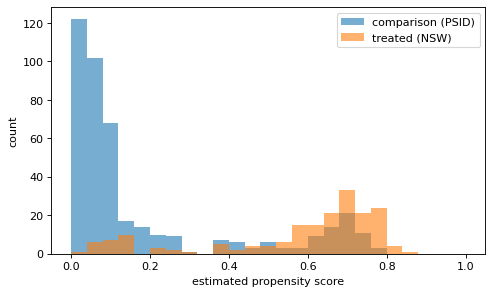

In [7]:
df["pscore"] = ps.pscore.values

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 26)
ax.hist(df.loc[df["treat"] == 0, "pscore"], bins=bins, alpha=0.6, label="comparison (PSID)")
ax.hist(df.loc[df["treat"] == 1, "pscore"], bins=bins, alpha=0.6, label="treated (NSW)")
ax.set_xlabel("estimated propensity score")
ax.set_ylabel("count")
ax.legend()
plt.show()

对照组大量堆在 0 附近。这些人的特征与培训参加者差别很大，几乎不可能参加项目，对估计 ATT 帮不上忙。处理组则集中在 0.5 以上，那里的对照个体不多。

这说明两件事。能为处理组提供可比对象的对照个体远少于 429 人。少数得分较高的对照个体会被反复使用，或者得到很大的权重，估计的方差会因此变大。

倾向得分模型的目的是**平衡协变量**，不是预测处理。判断一个倾向得分模型好不好，看的是用它匹配或加权之后协变量是否平衡，而不是它的拟合优度。

## 6. 匹配

最近邻匹配为每个处理个体找一个倾向得分最接近的对照个体。`sp.match` 是匹配和加权方法的统一入口，默认是 1 对 1 的倾向得分最近邻匹配，允许重复使用对照个体，估计 ATT。相当于 Stata 的 `teffects psmatch` 或 `psmatch2`。

In [8]:
psm = sp.match(df, y="re78", treat="treat", covariates=covs)

print(f"倾向得分最近邻匹配: ATT = {psm.estimate:.0f}  (se {psm.se:.0f})    实验基准 {BENCHMARK}")
print(f"95% 置信区间: [{psm.ci[0]:.0f}, {psm.ci[1]:.0f}]")

倾向得分最近邻匹配: ATT = 1969  (se 1182)    实验基准 1794


95% 置信区间: [-347, 4285]


点估计 1,969 美元，离实验基准很近。标准误也很大，置信区间从负值一直延伸到 4,000 多。

### 匹配之后必须重新检查平衡

匹配的目的是让两组在协变量上可比。有没有做到，要看匹配后的平衡。结果对象的 `matched_data` 里有一列 `_weight`，记录每个个体在匹配样本中的权重，没被用到的对照个体为缺失。平衡诊断把缺失的权重当作 0。

In [9]:
matched = psm.matched_data

used = matched[(matched["treat"] == 0) & (matched["_weight"] > 0)]
print(f"被用到的对照个体: {len(used)} / 429")
print(f"其中被使用次数最多的一个被用了 {used['_weight'].max():.0f} 次")

被用到的对照个体: 88 / 429
其中被使用次数最多的一个被用了 12 次


In [10]:
bal_psm = sp.balance_diagnostics(matched, treatment="treat", covariates=covs, weights="_weight")
bal_psm.table[["mean_treat", "mean_control", "weighted_mean_control", "smd_raw", "smd_weighted"]].round(3)

,mean_treat,mean_control,weighted_mean_control,smd_raw,smd_weighted
variable,,,,,
age,25.816,28.030,24.103,-0.242,0.203
educ,10.346,10.235,10.378,0.045,-0.014
black,0.843,0.203,0.838,1.668,0.015
hispanic,0.059,0.142,0.065,-0.277,-0.022
married,0.189,0.513,0.130,-0.719,0.162
nodegree,0.708,0.597,0.703,0.235,0.012
re74,2095.574,5619.237,2336.463,-0.596,-0.050
re75,1532.055,2466.484,1503.929,-0.287,0.010


429 个对照个体只用到了 88 个，有的被重复使用了很多次。这印证了上一节重叠图给出的判断。

匹配后大多数变量的 SMD 降到了 0.05 以内。最严重的 `black` 从 1.67 降到 0.02 以下。但 `age` 和 `married` 仍然是 0.20 和 0.16，没有达到 0.1 的标准。匹配并不保证平衡，所以这一步不能省。

平衡不理想时，常见的处理办法有三种。修改倾向得分模型（加入平方项和交互项），换一种匹配方式，或者在匹配样本上再做回归调整。**这些调整都只看协变量，不看结果变量**。这是匹配方法的一条重要纪律。先把平衡调好，最后才看一眼效应估计，这样就不会不自觉地挑选「好看」的结果。

Love plot 把调整前后的 SMD 画在一张图上。

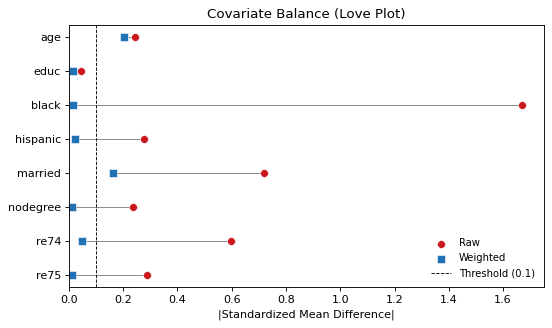

In [11]:
fig, ax = sp.love_plot(psm)   # 直接把匹配结果交给它
plt.show()

### 匹配方式的选择

匹配有很多调节选项。下面换几种设定看结果变化多大。

- `n_matches=3`。每个处理个体配 3 个对照，方差更小，但第 2、第 3 近的匹配质量更差。
- `caliper=0.05`。只接受倾向得分差距在 0.05 以内的匹配。
- `method="nnmatch"`。不用倾向得分，直接在协变量空间里按马氏距离找最近邻，并做偏差校正。相当于 Stata 的 `teffects nnmatch`。
- `method="full"`。最优全匹配，每个个体都被用上。

In [12]:
variants = {
    "PSM, 1 neighbor": {},
    "PSM, 3 neighbors": {"n_matches": 3},
    "PSM, caliper 0.05": {"caliper": 0.05},
    "covariate NN, bias-adjusted": {"method": "nnmatch", "estimand": "ATT", "bias_adjust": True},
    "optimal full matching": {"method": "full"},
}
match_results = {
    label: sp.match(df, y="re78", treat="treat", covariates=covs, **kwargs)
    for label, kwargs in variants.items()
}
pd.DataFrame(
    [(label, r.estimate, r.se) for label, r in match_results.items()],
    columns=["matching method", "att", "se"],
).round(0)

,matching method,att,se
0,"PSM, 1 neighbor",1969.0,1182.0
1,"PSM, 3 neighbors",1574.0,1077.0
2,"PSM, caliper 0.05",1975.0,1179.0
3,"covariate NN, bias-adjusted",28.0,1208.0
4,optimal full matching,1637.0,813.0


基于倾向得分的几种匹配给出约 1,600 到 2,000 美元的估计。直接在协变量上匹配的结果则接近 0。

差别这么大并不意外。倾向得分匹配和协变量匹配对「相似」的定义不同，在一个重叠很差的样本里，它们选出的对照个体可以很不一样。标准误在 800 到 1,200 之间，这些估计之间的差异在统计上并不显著。对一个只有 185 个处理个体的样本，这是应有的谦逊。

## 7. 逆概率加权

加权是匹配之外的另一条路。不丢弃任何人，而是给对照个体加权，使加权后的对照组在协变量分布上看起来像处理组。估计 ATT 时，处理个体的权重为 1，对照个体的权重是倾向得分的胜算（odds）。

$$
w_i = \frac{e(X_i)}{1 - e(X_i)} \qquad (D_i = 0).
$$

倾向得分高的对照个体与参加者更相似，得到更大的权重。倾向得分接近 0 的对照个体权重接近 0，相当于被自动忽略。

In [13]:
ipw = sp.ipw(df, y="re78", treat="treat", covariates=covs, estimand="ATT", se_method="sandwich")
print(f"IPW: ATT = {ipw.estimate:.0f}  (se {ipw.se:.0f})    实验基准 {BENCHMARK}")

IPW: ATT = 1214  (se 798)    实验基准 1794


In [14]:
# 把权重拿出来看一看
df["w_ipw"] = np.asarray(sp.ps_weights(df["pscore"], df["treat"], estimand="ATT"))

ctrl_w = df.loc[df["treat"] == 0, "w_ipw"]
print("对照个体的 ATT 权重分布:")
print(ctrl_w.describe().round(3).to_string())
print(f"\n权重最大的 10 个对照个体占对照组总权重的 {ctrl_w.nlargest(10).sum() / ctrl_w.sum():.1%}")
print(f"对照组的有效样本量: {sp.ess(ctrl_w.values):.0f}   (名义样本量 {len(ctrl_w)})")

对照个体的 ATT 权重分布:
count    429.000
mean       0.436
std        0.793
min        0.009
25%        0.040
50%        0.082
75%        0.242
max        3.743

权重最大的 10 个对照个体占对照组总权重的 16.9%
对照组的有效样本量: 100   (名义样本量 429)


**有效样本量**（effective sample size）是 $(\sum w_i)^2 / \sum w_i^2$。权重越不均匀，它越小。429 个对照个体加权之后只相当于大约 100 个等权重的观测。这个数字比名义样本量更能说明估计的精度。

加权之后同样要检查平衡。

In [15]:
bal_ipw = sp.balance_diagnostics(df, treatment="treat", covariates=covs, weights="w_ipw")
bal_ipw.table[["mean_treat", "weighted_mean_control", "smd_raw", "smd_weighted"]].round(3)

,mean_treat,weighted_mean_control,smd_raw,smd_weighted
variable,,,,
age,25.816,24.966,-0.242,0.094
educ,10.346,10.403,0.045,-0.025
black,0.843,0.845,1.668,-0.006
hispanic,0.059,0.059,-0.277,0.001
married,0.189,0.171,-0.719,0.048
nodegree,0.708,0.690,0.235,0.040
re74,2095.574,2106.045,-0.596,-0.002
re75,1532.055,1496.541,-0.287,0.012


加权后所有变量的 |SMD| 都降到了 0.1 以内，比 1 对 1 匹配的平衡更好。

IPW 的弱点是对极端权重敏感。倾向得分接近 1 的对照个体会得到非常大的权重，少数几个人就能左右结果。常见的应对是截断权重，或者去掉倾向得分极端的观测（`sp.trimming`）。这些操作会改变估计的目标总体，汇报时要说明。

## 8. 熵平衡

倾向得分加权是「先拟合模型，再检查平衡，不好再改模型」的循环。Hainmueller (2012) 提出的熵平衡把顺序倒过来。直接把「加权后对照组的协变量均值等于处理组」写成约束，在满足约束的权重里找离均匀权重最近的一组。

平衡不再是需要检查的结果，而是求解时的前提。

In [16]:
eb = sp.ebalance(df, y="re78", treat="treat", covariates=covs)

print(f"熵平衡: ATT = {eb.estimate:.0f}  (se {eb.se:.0f})    实验基准 {BENCHMARK}")
print(f"对照组的有效样本量: {eb.model_info['eff_sample_size']:.0f}")
eb.detail[["covariate", "mean_treated", "mean_control_raw", "mean_control_balanced", "smd_before", "smd_after"]].round(3)

熵平衡: ATT = 1273  (se 790)    实验基准 1794
对照组的有效样本量: 98


,covariate,mean_treated,mean_control_raw,mean_control_balanced,smd_before,smd_after
0,age,25.816,28.030,25.816,-0.242,-0.0
1,educ,10.346,10.235,10.346,0.045,-0.0
2,black,0.843,0.203,0.843,1.668,0.0
3,hispanic,0.060,0.142,0.060,-0.277,-0.0
4,married,0.189,0.513,0.189,-0.720,-0.0
5,nodegree,0.708,0.597,0.708,0.235,-0.0
6,re74,2095.574,5619.236,2095.574,-0.596,-0.0
7,re75,1532.055,2466.484,1532.055,-0.287,-0.0


加权后对照组的每个协变量均值都与处理组**完全相等**，`smd_after` 全部为 0。

要注意熵平衡只平衡了你要求它平衡的矩，默认是均值。如果认为方差或交互项也重要，可以通过 `moments=2` 等参数加入更多约束。约束越多，权重越不均匀，有效样本量越小。

## 9. 双重稳健

回归调整依赖结果模型设定正确。加权依赖倾向得分模型设定正确。增广逆概率加权（AIPW）把两者结合起来，**只要其中一个模型正确，估计量就是一致的**，所以叫双重稳健。

直观上，AIPW 先用结果模型做预测，再用倾向得分加权后的残差去修正预测的偏差。结果模型对了，残差的修正项期望为 0。结果模型错了但倾向得分对了，修正项恰好把偏差补回来。

In [17]:
aipw = sp.aipw(df, y="re78", treat="treat", covariates=covs, estimand="ATT")

print(f"AIPW: ATT = {aipw.estimate:.0f}  (se {aipw.se:.0f})    实验基准 {BENCHMARK}")
print(f"倾向得分被截断的观测数: {aipw.model_info['n_propensity_clipped']}  (截断界 {aipw.model_info['trim']})")

AIPW: ATT = 1188  (se 864)    实验基准 1794
倾向得分被截断的观测数: 6  (截断界 0.01)


`sp.aipw` 默认使用交叉拟合，并把倾向得分截断在 [0.01, 0.99] 之内，被截断的观测数会写在结果里。

双重稳健不是双重保险。两个模型都错的时候它没有任何保证，而且它同样依赖条件独立假设。它保护的只是函数形式设错的风险。

## 10. 把所有估计放在一起

In [18]:
summary_rows = [
    ("raw difference", naive, np.nan),
    ("OLS regression", ols.params["treat"], ols.std_errors["treat"]),
    ("PSM, 1 neighbor", psm.estimate, psm.se),
    ("PSM, 3 neighbors", match_results["PSM, 3 neighbors"].estimate, match_results["PSM, 3 neighbors"].se),
    ("optimal full matching", match_results["optimal full matching"].estimate, match_results["optimal full matching"].se),
    ("covariate NN, bias-adjusted", match_results["covariate NN, bias-adjusted"].estimate, match_results["covariate NN, bias-adjusted"].se),
    ("IPW", ipw.estimate, ipw.se),
    ("entropy balancing", eb.estimate, eb.se),
    ("AIPW (doubly robust)", aipw.estimate, aipw.se),
]
summary = pd.DataFrame(summary_rows, columns=["method", "att", "se"])
summary["ci_lower"] = summary["att"] - 1.96 * summary["se"]
summary["ci_upper"] = summary["att"] + 1.96 * summary["se"]
summary.round(0)

,method,att,se,ci_lower,ci_upper
0,raw difference,-635.0,NaN,NaN,NaN
1,OLS regression,1548.0,741.0,97.0,3000.0
2,"PSM, 1 neighbor",1969.0,1182.0,-347.0,4285.0
3,"PSM, 3 neighbors",1574.0,1077.0,-536.0,3684.0
4,optimal full matching,1637.0,813.0,44.0,3230.0
5,"covariate NN, bias-adjusted",28.0,1208.0,-2339.0,2395.0
6,IPW,1214.0,798.0,-350.0,2778.0
7,entropy balancing,1273.0,790.0,-275.0,2821.0
8,AIPW (doubly robust),1188.0,864.0,-506.0,2882.0


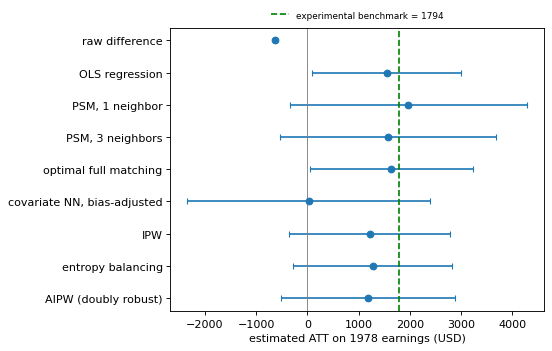

In [19]:
plot_df = summary.iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(plot_df["att"], plot_df["method"], xerr=1.96 * plot_df["se"].fillna(0), fmt="o", capsize=3)
ax.axvline(BENCHMARK, color="green", ls="--", label=f"experimental benchmark = {BENCHMARK}")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("estimated ATT on 1978 earnings (USD)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

这张图是整个教程的要点。

- **任何调整都比不调整好**。原始均值差的符号是错的，所有调整过的估计都不为负。
- **多数方法落在 1,200 到 2,000 美元之间**，与实验基准 1,794 在同一个范围。直接在协变量上匹配的那一个是例外。
- **每个置信区间都很宽**。它们全部包含实验基准，其中多数也包含 0。培训效果在 5% 水平上是否显著，取决于选了哪种方法。
- **方法之间的差异和单个估计的标准误在同一个量级**。

最后一点值得多说一句。在真实研究里没有实验基准可供对照。如果只跑了一种方法并且碰巧得到了一个显著的结果，读者无从判断它有多稳。把几种合理的方法并排报告，是对读者负责的做法。LaLonde (1986) 最初的结论正是，非实验估计量之间差别很大，并且常常找不回实验结果。后来的文献表明，丰富的处理前变量（尤其是处理前的收入）和对重叠的认真对待能大大改善这一点。

## 11. 敏感性分析

以上所有方法都假设没有未观测的混淆因素。这个假设无法检验，但可以问一个退一步的问题。

> 一个未观测的混淆因素要有多强，才能把估计值变成 0？

Cinelli and Hazlett (2020) 为线性回归给出了一套回答这个问题的工具。`sp.sensemakr` 对应 R 和 Stata 的 `sensemakr`。它的核心指标是**稳健性值**（robustness value，RV）。如果一个未观测混淆因素能同时解释处理变量和结果变量残余变异的 RV 这么大的比例，估计值就会降到 0。

为了让这个数字有参照，可以用已观测的协变量作基准。下面问的是，如果存在一个和 `re74` 或 `black` 同样强的未观测混淆因素，结论会怎样。

In [20]:
sens = sp.sensemakr(df, y="re78", treat="treat", controls=covs, benchmark=["re74", "black"])

print(f"回归估计                : {sens['beta_treat']:.0f}  (se {sens['se_treat']:.0f})")
print(f"处理变量对结果的偏 R²    : {sens['partial_r2_yd']:.4f}")
print(f"稳健性值 RV（估计降到 0）: {sens['rv_q']:.3f}")
print(f"稳健性值 RV（不再显著） : {sens['rv_qa']:.4f}")
print()
print(sens["benchmark_table"][["variable", "r2dz_x", "r2yz_dx", "adjusted_estimate", "adjusted_lower_CI", "adjusted_upper_CI"]].round(3).to_string(index=False))

回归估计                : 1548  (se 781)
处理变量对结果的偏 R²    : 0.0065
稳健性值 RV（估计降到 0）: 0.077
稳健性值 RV（不再显著） : 0.0007

variable  r2dz_x  r2yz_dx  adjusted_estimate  adjusted_lower_CI  adjusted_upper_CI
    re74   0.007    0.043           1216.725           -290.343           2723.793
   black   0.406    0.010            -57.118          -2039.909           1925.673


读法如下。

- **RV = 7.7%**。一个未观测因素如果能解释处理和结果各 7.7% 的残余变异，估计值就会降到 0。
- **使结果不再显著的 RV 不到 0.1%**。估计本来就处在显著性的边缘，极弱的混淆就能让它失去显著性。
- **基准比较**。一个与 `re74` 同样强的未观测混淆因素会把估计值从 1,548 降到 1,217。一个与 `black` 同样强的会把它降到 −57，效应完全消失。

`black` 在这份数据里是极强的混淆因素，处理组和对照组的种族构成差别悬殊。是否还存在同等强度的遗漏变量，需要靠对项目招募过程的了解来判断，数据回答不了。敏感性分析的作用是把这个问题从「有没有遗漏变量」变成「遗漏变量要多强」，让讨论可以具体地进行。

对于二值或比值类的结果，类似的工具是 `sp.evalue`。

## 12. 小结

做基于可观测变量的因果推断时可以对照这份清单。

1. **论证条件独立假设**。参加决定是怎么做出的，哪些变量影响它，它们是否都在 $X$ 里。只放处理之前确定的变量。
2. **明确估计目标**。ATT 还是 ATE。
3. **调整之前先看平衡**（`sp.balance_table`）。用 SMD，不用 p 值。
4. **估计倾向得分并检查重叠**（`sp.pscore`）。重叠差的时候，考虑缩小目标总体并如实说明。
5. **调整之后再看平衡**（`sp.balance_diagnostics`、`sp.love_plot`）。不平衡就改模型或换方法。这个过程不看结果变量。
6. **汇报有效样本量**（`sp.ess`）。
7. **并排报告几种方法**。回归、匹配（`sp.match`）、加权（`sp.ipw`、`sp.ebalance`）、双重稳健（`sp.aipw`）。
8. **做敏感性分析**（`sp.sensemakr`、`sp.evalue`）。

延伸阅读见 `docs/guides/choosing_matching_estimator.md`。

### 本教程用到的方法的文献

下面的 BibTeX 条目直接取自 StatsPAI 核验过的 `paper.bib`。

In [21]:
keys = [
    "lalonde1986evaluating",
    "dehejia1999causal",
    "rosenbaum1983central",
    "abadie2006large",
    "hainmueller2012entropy",
    "robins1994estimation",
    "cinelli2020making",
]
print(sp.bibtex(keys))

@article{lalonde1986evaluating,
  title={Evaluating the Econometric Evaluations of Training Programs with Experimental Data},
  author={LaLonde, Robert J.},
  journal={American Economic Review},
  volume={76},
  number={4},
  pages={604--620},
  year={1986},
  annote={No DOI: AEA's Crossref deposits for the American Economic Review begin at volume 89 (1999) -- a query on the journal's ISSN returns zero records before then. Verified 2026-08-24.}
}

@article{dehejia1999causal,
  title={Causal Effects in Nonexperimental Studies: Reevaluating the Evaluation of Training Programs},
  author={Dehejia, Rajeev H. and Wahba, Sadek},
  journal={Journal of the American Statistical Association},
  volume={94},
  number={448},
  pages={1053--1062},
  year={1999},
  doi={10.1080/01621459.1999.10473858}
}

@article{rosenbaum1983central,
  title={The central role of the propensity score in observational studies for causal effects},
  author={Rosenbaum, Paul R. and Rubin, Donald B.},
  journal={Biometri